# Real Nanonis scan workflow tutorial

This notebook exercises the complete `nanonis.workflows.scan` API against a real Nanonis controller. It uses the real TCP command registry, not a demo controller.

**Do not use Run All on hardware.** Run one cell at a time and inspect every response. Pure-Python and read-only cells come first. Cells that write scan settings, start a scan, grab buffers, or stop a scan require separate typed confirmations. All distances and speeds use SI units (metres, seconds, metres/second); frame angle is degrees clockwise.

This implementation deliberately preserves the raw `FrameDataGrab` row order. The physical meaning of row 0 and whether an up/down scan reverses rows must be established on your controller before data is flipped or assigned physical Y coordinates.

## 1. Import the controller and every public scan helper

Start Jupyter in the repository root or `examples/` directory. If needed, install the package with `python -m pip install -e .`. QCoDeS is not needed for scan acquisition.

In [ ]:
from __future__ import annotations

import logging
import sys
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path

import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "nanonis").exists():
    ROOT = ROOT.parent
if not (ROOT / "src" / "nanonis").exists():
    raise RuntimeError("Start Jupyter in the repository root or examples directory")
sys.path.insert(0, str(ROOT / "src"))

from nanonis.command import NanonisController  # noqa: E402
from nanonis.workflows import (  # noqa: E402
    BiasRestoreMode,
    NaNPolicy,
    NonFiniteScanDataError,
    SafetyPreflightError,
    ScanResponseError,
    ScanTimeoutError,
    StateRestorationError,
    TipRestorePolicy,
)
from nanonis.workflows.scan import (  # noqa: E402
    ACTION_START, ACTION_STOP, DATA_BACKWARD, DATA_FORWARD,
    DIRECTION_DOWN, DIRECTION_UP,
    DataDirection, KeepConstant, SaveMode, ScanDirection,
    ScanChannelImage, ScanConfig, ScanFrame, ScanProps, ScanResult,
    ScanSafetyPolicy, ScanSettings, ScanSpeed, ScanWorkflow,
    apply_scan_nan_policy,
    decode_autopaste_get, decode_autosave_get, decode_keep_constant_get,
    decode_on_off_get, decode_save_mode_get, decode_speed_keep_get,
    encode_autopaste_set, encode_autosave_set, encode_keep_constant_set,
    encode_on_off_set, encode_save_mode_set, encode_speed_keep_set,
    estimate_scan_duration, grab_frame, inspect_non_finite_scan_data,
    nanonis_line_timeout_ms, nanonis_timeout_ms,
    normalize_scan, normalize_scan_images,
    preflight_scan, recover_scan, resolve_acquisition_timeout, scan,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
print("Repository root:", ROOT)

## 2. API map and protocol conversions (no hardware I/O)

The workflow API is split into four layers:

- **Configuration and policy:** `ScanConfig` describes one requested frame; `ScanSafetyPolicy` contains rig-approved hard limits. Constructing either sends no commands. The type aliases `ScanDirection`, `DataDirection`, `SaveMode`, and `KeepConstant` document the accepted string values.
- **Controller state:** `ScanSettings.snapshot(client)` reads frame, buffer, properties, and speed. `.patch(config)` is local and immutable. `.apply(client)` and `.restore(client)` write settings in frame → buffer → speed → properties order.
- **Acquisition:** `preflight_scan`, `estimate_scan_duration`, `nanonis_timeout_ms`, `nanonis_line_timeout_ms`, `resolve_acquisition_timeout`, `ScanWorkflow.run`, `ScanWorkflow.run_partial`, `grab_frame`, and `recover_scan`. Normally call `ScanWorkflow.run` for a full frame or `ScanWorkflow.run_partial` to stop after N image rows (section 13); the lower-level helpers are exposed for characterization and diagnostics.
- **Results:** `normalize_scan_images`, `normalize_scan`, `inspect_non_finite_scan_data`, and `apply_scan_nan_policy`. `ScanChannelImage` owns a frozen 2-D array; `ScanResult` contains the images and acquisition provenance.

The conversion functions are important because Nanonis Get and Set values are asymmetric. For example, read-side off is `0`, but write-side off is `2`; write-side `0` means no change. Never echo a Get integer directly into the corresponding Set command.

In [3]:
print("Scan.Action constants:", {
    "start": ACTION_START, "stop": ACTION_STOP,
    "up": DIRECTION_UP, "down": DIRECTION_DOWN,
})
print("FrameDataGrab constants:", {"forward": DATA_FORWARD, "backward": DATA_BACKWARD})

print("on/off Get -> semantic -> Set")
for raw in (0, 1):
    semantic = decode_on_off_get(raw)
    print(raw, "->", semantic, "->", encode_on_off_set(semantic))
print("on/off no-change Set value:", encode_on_off_set(None))

print("autosave/autopaste Get -> semantic -> Set")
for raw in (0, 1, 2):
    mode = decode_save_mode_get(raw)
    print(raw, "->", mode, "->", encode_save_mode_set(mode))
assert decode_autosave_get(1) == "next"
assert decode_autopaste_get(2) == "off"
assert encode_autosave_set("all") == 1
assert encode_autopaste_set("off") == 3

print("speed selector Get -> semantic -> Set")
for raw in (0, 1):
    selector = decode_keep_constant_get(raw)
    print(raw, "->", selector, "->", encode_keep_constant_set(selector))
assert decode_speed_keep_get(0) == "linear_speed"
assert encode_speed_keep_set("time_per_line") == 2

Scan.Action constants: {'start': 0, 'stop': 1, 'up': 1, 'down': 0}
FrameDataGrab constants: {'forward': 1, 'backward': 0}
on/off Get -> semantic -> Set
0 -> False -> 2
1 -> True -> 1
on/off no-change Set value: 0
autosave/autopaste Get -> semantic -> Set
0 -> all -> 1
1 -> next -> 2
2 -> off -> 3
speed selector Get -> semantic -> Set
0 -> linear_speed -> 1
1 -> time_per_line -> 2


## 3. Configure and open the real TCP connection

`HOST` and `PORT` must match the Nanonis TCP server. The prior live workflow example used port 6503; change it if your command server uses another port. `timeout` is the ordinary socket timeout. The workflow temporarily supplies its own longer timeout only to `Scan.WaitEndOfScan`. Connecting does not move the tip or start a scan.

In [10]:
HOST = "127.0.0.1"
PORT = 6503
COMMAND_CONFIG = ROOT / "configs" / "commands"

nanonis = NanonisController(
    host=HOST,
    port=PORT,
    config_path=COMMAND_CONFIG,
    timeout=10.0,
)
nanonis.connect()
print("Connected:", nanonis.is_connected)
print("Transport state:", nanonis.transport_state)

Connected: True
Transport state: TransportState.READY


## 4. Read-only live characterization

These commands do not write settings or start motion. They establish the piezo range, available signal indexes, scan status, and the exact raw response keys on your controller.

Important checks:

- `Piezo.RangeGet` returns **total** X/Y/Z travel in metres; preflight uses ±range/2 around zero minus the policy margin.
- `Signals.NamesGet` determines valid `channel_indexes`. Use the printed numeric indexes, not list positions guessed from the GUI.
- `Scan.StatusGet` must report `scan_status=0` before a one-shot workflow begins.
- Record the real raw `autopaste` value. The implementation uses the documented All/Next/Off read encoding, but the plan flags this field for live confirmation.

In [11]:
piezo_range = nanonis.send("Piezo.RangeGet")
signal_info = nanonis.send("Signals.NamesGet")
scan_status = nanonis.send("Scan.StatusGet")
raw_frame = nanonis.send("Scan.FrameGet")
raw_buffer = nanonis.send("Scan.BufferGet")
raw_props = nanonis.send("Scan.PropsGet")
raw_speed = nanonis.send("Scan.SpeedGet")

print("Piezo range:", piezo_range)
print("Scan status:", scan_status)
print("Frame response:", raw_frame)
print("Buffer response:", raw_buffer)
print("Properties response:", raw_props)
print("Speed response:", raw_speed)
print("Raw autopaste value:", raw_props.get("autopaste"))
print("Available signals:")
for index, name in enumerate(signal_info["signals_names"]):
    if name:
        print(f"{index:3d}: {name}")

Piezo range: {'range_x_m': 3.000000106112566e-06, 'range_y_m': 3.000000106112566e-06, 'range_z_m': 1.500000053056283e-06}
Scan status: 0
Frame response: {'center_x_m': 0.0, 'center_y_m': 0.0, 'width_m': 1.4999999464748726e-08, 'height_m': 1.4999999464748726e-08, 'angle_deg': 0.0}
Buffer response: {'num_channels': 5, 'channel_indexes': array([ 0,  1,  2,  3, 76], dtype='>i4'), 'pixels': 256, 'lines': 256}
Properties response: {'continuous_scan': 0, 'bouncy_scan': 1, 'autosave': 2, 'series_name': 'unnamed', 'comment': 'Conservative scan workflow characterization', 'modules_names_size': 0, 'modules_names_number': 0, 'modules_names': [], 'size_of_num_parameters_per_module_array': 0, 'num_parameters_per_module_array': array([], dtype='>i4'), 'parameters_rows': 0, 'parameters_columns': 0, 'parameters': [], 'autopaste': 2}
Speed response: {'forward_linear_speed_m_s': 2.929687354935595e-07, 'backward_linear_speed_m_s': 2.929687354935595e-07, 'forward_time_per_line_s': 0.05119999870657921, 'bac

## 5. Build a typed settings snapshot (read only)

`ScanSettings.snapshot(nanonis)` sends `FrameGet`, `BufferGet`, `PropsGet`, and `SpeedGet`, validates the responses, and returns an immutable object. Its nested types are:

- `ScanFrame`: centre X/Y, width, height, and clockwise angle. `.corners()` calculates all four rotated controller-coordinate corners.
- `ScanSpeed`: forward/backward linear speeds, times per line, which parameter is held constant, and speed ratio.
- `ScanProps`: continuous, bouncy, autosave, autopaste, series/comment text, module names, and parameter headers.
- `ScanSettings`: frame plus buffered channels, pixels, lines, properties, and speed.

No setters are sent in this section.

In [12]:
original_settings = ScanSettings.snapshot(nanonis)
assert isinstance(original_settings.frame, ScanFrame)
assert isinstance(original_settings.speed, ScanSpeed)
assert isinstance(original_settings.props, ScanProps)

print(original_settings)
print("Rotated frame corners (m):")
for corner in original_settings.frame.corners():
    print(corner)

ScanSettings(frame=ScanFrame(center_x=0.0, center_y=0.0, width=1.4999999464748726e-08, height=1.4999999464748726e-08, angle=0.0), channels=(0, 1, 2, 3, 76), pixels=256, lines=256, props=ScanProps(continuous=False, bouncy=True, autosave='off', series_name='unnamed', comment='Conservative scan workflow characterization', modules_names=(), num_parameters_per_module=(), parameters=(), autopaste='off'), speed=ScanSpeed(forward_linear_speed=2.929687354935595e-07, backward_linear_speed=2.929687354935595e-07, forward_time_per_line=0.05119999870657921, backward_time_per_line=0.05119999870657921, keep_parameter_constant='time_per_line', speed_ratio=1.0))
Rotated frame corners (m):
(-7.499999732374363e-09, -7.499999732374363e-09)
(-7.499999732374363e-09, 7.499999732374363e-09)
(7.499999732374363e-09, -7.499999732374363e-09)
(7.499999732374363e-09, 7.499999732374363e-09)


## 6. Define the rig-approved safety policy

Replace every example below with values approved for this scanner. These values are limits, not requested scan settings.

- `max_pixels`, `max_lines`: maximum raster dimensions this workflow may apply.
- `piezo_safety_margin`: distance removed from each ±half-range boundary. It must leave positive usable X and Y travel.
- `min_line_time`, `max_line_time`: allowed forward and backward seconds per line.
- `min_linear_speed`, `max_linear_speed`: allowed effective forward/backward speeds in m/s. Choose bounds that include both the current settings and the expected controller readback.
- `tip`: optional `TipRestorePolicy`. Leave it `None` when `restore_tip_state=False`, which is the normal scan default. Enabling tip restoration can change feedback, bias, and current setpoint during cleanup.

In [13]:
safety_policy = ScanSafetyPolicy(
    max_pixels=1024,
    max_lines=1024,
    piezo_safety_margin=10e-9,  # m; replace with a rig-approved margin
    min_line_time=1e-3,         # s/line
    max_line_time=10.0,         # s/line
    min_linear_speed=1e-12,     # m/s
    max_linear_speed=1e-2,      # m/s
    tip=None,
)
print(safety_policy)

ScanSafetyPolicy(max_pixels=1024, max_lines=1024, piezo_safety_margin=1e-08, min_line_time=0.001, max_line_time=10.0, min_linear_speed=1e-12, max_linear_speed=0.01, tip=None)


### Optional tip-restoration policy (construct only; no hardware I/O)

This demonstrates `TipRestorePolicy`; it does not activate it. `DIRECT` performs one `Bias.Set` during restoration. `allow_zero_crossing=False` prevents restoring across zero. For stepped or external restoration, configure the corresponding ramp or callback. Attach this object with `replace(safety_policy, tip=tip_restore_policy)` only after lab approval, and set `ScanConfig.restore_tip_state=True`.

In [14]:
tip_restore_policy = TipRestorePolicy(
    bias_restore_mode=BiasRestoreMode.DIRECT,
    bias_ramp=None,
    allow_zero_crossing=False,
    feedback_off_during_restore=True,
)
print("Constructed but NOT activated:", tip_restore_policy)

Constructed but NOT activated: TipRestorePolicy(bias_restore_mode=<BiasRestoreMode.DIRECT: 'direct'>, bias_ramp=None, allow_zero_crossing=False, feedback_off_during_restore=True, external_bias_restorer=None)


## 7. Define a conservative real scan

Constructing `ScanConfig` performs structural validation and sends no commands. Important parameters:

- `channel_indexes`: unique signal indexes printed above. At least one is required.
- `direction`: physical scan direction; `"up"` sends 1 and `"down"` sends 0.
- `center_x`, `center_y`, `width`, `height`, `angle`: optional frame overrides. `None` preserves the snapshot field. Positive angle is clockwise.
- `pixels`, `lines`: optional raster dimensions, each at least 2.
- `forward_line_time`, `backward_line_time`: optional seconds/line. Providing either makes time-per-line the constant speed parameter.
- `speed_ratio`: optional controller speed ratio.
- `autosave`: `"all"`, `"next"`, `"off"`, or `None`; it is not a Boolean.
- `data_directions`: buffers to retrieve after completion. This does not change raster duration because every line has forward and backward movement.
- `acquisition_timeout`: socket timeout in seconds. `None` computes a safe value. An explicit value must exceed the Nanonis-side timeout.
- `recovery_timeout`, `status_poll_interval`: stop-confirmation deadline and polling interval after an unconfirmed failure.
- `restore_state`: restore frame/buffer/speed/properties on every exit. Keep this `True` for initial hardware testing.
- `restore_tip_state`: opt-in tunnel-condition restoration; requires `safety_policy.tip`.

In [15]:
# Replace channel 0 after checking the signal list above.
config = ScanConfig(
    channel_indexes=(0,),
    direction="up",
    center_x=0.0,
    center_y=0.0,
    width=10e-9,
    height=10e-9,
    angle=0.0,
    pixels=16,
    lines=16,
    forward_line_time=0.10,
    backward_line_time=0.05,
    speed_ratio=None,
    autosave="off",
    series_name="scan-workflow-live-test",
    comment="Conservative scan workflow characterization",
    data_directions=("forward", "backward"),
    grab_data=True,
    acquisition_timeout=None,
    recovery_timeout=15.0,
    status_poll_interval=0.1,
    restore_state=True,
    restore_tip_state=False,
)
print(config)

ScanConfig(channel_indexes=(0,), direction='up', center_x=0.0, center_y=0.0, width=1e-08, height=1e-08, angle=0.0, pixels=16, lines=16, forward_line_time=0.1, backward_line_time=0.05, speed_ratio=None, autosave='off', series_name='scan-workflow-live-test', comment='Conservative scan workflow characterization', data_directions=('forward', 'backward'), grab_data=True, acquisition_timeout=None, recovery_timeout=15.0, status_poll_interval=0.1, restore_state=True, restore_tip_state=False)


## 8. Preview snapshot-and-patch and timeout math (read only/local only)

`original_settings.patch(config)` creates a new settings object in memory. It does not mutate the snapshot or send setters. Continuous mode is forced off in the patched object because a finite `WaitEndOfScan` cannot complete for a continuous scan.

`estimate_scan_duration` uses `lines × (forward time/line + backward time/line) + positioning margin`. `nanonis_timeout_ms` adds the controller-side margin. `resolve_acquisition_timeout` produces the longer per-command socket timeout, or validates your explicit value.

In [16]:
original_settings = ScanSettings.snapshot(nanonis)  # getters only
requested_settings = original_settings.patch(config)  # local only
estimated_duration = estimate_scan_duration(requested_settings)
controller_timeout_ms = nanonis_timeout_ms(config, requested_settings)
socket_timeout = resolve_acquisition_timeout(
    config, requested_settings, controller_timeout_ms=controller_timeout_ms,
    estimate=estimated_duration,
)

print("Original settings:", original_settings)
print("Requested local settings:", requested_settings)
print("Continuous forced off in request:", requested_settings.props.continuous)
print("Requested frame corners (m):", requested_settings.frame.corners())
print("Estimated acquisition duration:", estimated_duration, "s")
print("Nanonis WaitEndOfScan timeout:", controller_timeout_ms, "ms")
print("Socket timeout:", socket_timeout, "s")

Original settings: ScanSettings(frame=ScanFrame(center_x=0.0, center_y=0.0, width=1.4999999464748726e-08, height=1.4999999464748726e-08, angle=0.0), channels=(0, 1, 2, 3, 76), pixels=256, lines=256, props=ScanProps(continuous=False, bouncy=True, autosave='off', series_name='unnamed', comment='Conservative scan workflow characterization', modules_names=(), num_parameters_per_module=(), parameters=(), autopaste='off'), speed=ScanSpeed(forward_linear_speed=2.929687354935595e-07, backward_linear_speed=2.929687354935595e-07, forward_time_per_line=0.05119999870657921, backward_time_per_line=0.05119999870657921, keep_parameter_constant='time_per_line', speed_ratio=1.0))
Requested local settings: ScanSettings(frame=ScanFrame(center_x=0.0, center_y=0.0, width=1e-08, height=1e-08, angle=0.0), channels=(0,), pixels=16, lines=16, props=ScanProps(continuous=False, bouncy=True, autosave='off', series_name='scan-workflow-live-test', comment='Conservative scan workflow characterization', modules_names

## 9. Run mandatory live preflight (read only)

`preflight_scan` reads piezo range, signal names, the four settings groups, and scan status. It checks all rotated frame corners, channel existence, dimension limits, forward/backward line times and linear speeds, the explicit timeout budget, and that the scan module is idle. It fails closed with `SafetyPreflightError` or `ScanResponseError`.

Passing preflight does not start a scan and does not write settings. Do not use `unsafe_skip_preflight=True` on normal hardware runs.

In [17]:
preflight_scan(nanonis, config, safety_policy)
print("LIVE SCAN PREFLIGHT PASSED")

LIVE SCAN PREFLIGHT PASSED


## 10. Optional settings apply/readback/restore test

This tests `ScanSettings.apply` and `.restore` without starting a scan. It **does write** `FrameSet`, `BufferSet`, `SpeedSet`, and `PropsSet`; then it reads back and restores the baseline in a `finally` block. `apply` and `restore` return `{field: exception}` mappings instead of stopping after the first failed setter.

Run this only after preflight and only when changing these GUI settings is safe. Killing the kernel or TCP server can prevent the `finally` restoration. The full workflow provides stronger transactional recovery. Edit the confirmation token in the next cell instead of using `input()`, which can wait invisibly in some notebook frontends.

In [18]:
# Safe default: edit this value to "APPLY_AND_RESTORE" to run the write test.
# An explicit token avoids a hidden, blocking input() prompt in some frontends.
settings_confirmation = "APPLY_AND_RESTORE"
if settings_confirmation == "APPLY_AND_RESTORE":
    print("Applying requested scan settings...", flush=True)
    baseline = ScanSettings.snapshot(nanonis)
    desired = baseline.patch(config)
    try:
        apply_failures = desired.apply(nanonis)
        print("Apply failures:", apply_failures)
        applied_readback = ScanSettings.snapshot(nanonis)
        print("Authoritative readback:", applied_readback)
    finally:
        print("Restoring original scan settings...", flush=True)
        restore_failures = baseline.restore(nanonis)
        print("Restore failures:", restore_failures)
        restored_readback = ScanSettings.snapshot(nanonis)
        print("Restored readback:", restored_readback)
else:
    print("Settings round-trip skipped")

Applying requested scan settings...
Apply failures: {}
Authoritative readback: ScanSettings(frame=ScanFrame(center_x=0.0, center_y=0.0, width=9.99999993922529e-09, height=9.99999993922529e-09, angle=0.0), channels=(0,), pixels=16, lines=16, props=ScanProps(continuous=False, bouncy=True, autosave='off', series_name='scan-workflow-live-test', comment='Conservative scan workflow characterization', modules_names=(), num_parameters_per_module=(), parameters=(), autopaste='off'), speed=ScanSpeed(forward_linear_speed=1.000000082740371e-07, backward_linear_speed=1.000000082740371e-07, forward_time_per_line=0.09999999403953552, backward_time_per_line=0.09999999403953552, keep_parameter_constant='time_per_line', speed_ratio=1.0))
Restoring original scan settings...
Restore failures: {}
Restored readback: ScanSettings(frame=ScanFrame(center_x=0.0, center_y=0.0, width=1.4999999464748726e-08, height=1.4999999464748726e-08, angle=0.0), channels=(0, 1, 2, 3, 76), pixels=256, lines=256, props=ScanProp

## 11. Start the real one-frame workflow

`scan(nanonis, safety_policy=..., nan_policy=...)` is the convenience factory; it returns the same `ScanWorkflow` class you could construct directly. `NaNPolicy.WARN` preserves completed images and logs NaN/Inf diagnostics.

`ScanWorkflow.run(config)` performs this transaction:

1. Read-only preflight.
2. Optional tip snapshot when `restore_tip_state=True`.
3. Scan settings snapshot, local patch, policy/timeout validation.
4. Frame → buffer → speed → properties writes; continuous is forced off.
5. Authoritative settings readback and another safety check.
6. `Scan.Action(Start, direction)` and `Scan.WaitEndOfScan(timeout_ms)` with a longer socket timeout.
7. `Scan.FrameDataGrab(channel, data_direction)` for each requested channel × direction.
8. Normalize/freeze images, then restore scan settings and optional tip state.

Any exception after a start attempt but before confirmed completion triggers reconnect → status → Stop → bounded status polling. Restoration writes occur only after transport and stopped-state confirmation. A completed result remains available in `StateRestorationError.result` if cleanup fails. Edit the explicit confirmation token in the next cell to start; while `workflow.run` is waiting synchronously for Nanonis, the cell remains busy until completion or timeout.

In [ ]:
workflow = scan(nanonis, safety_policy=safety_policy, nan_policy=NaNPolicy.WARN)
assert isinstance(workflow, ScanWorkflow)

# Safe default: edit this value to "START_SCAN" only when the hardware is ready.
# An explicit token avoids a hidden, blocking input() prompt in some frontends.
confirmation = "START_SCAN"
result = None
if confirmation != "START_SCAN":
    print('Scan not started. Set confirmation = "START_SCAN" and rerun when ready.')
else:
    print(
        f"Starting real scan (estimate {estimated_duration:.1f} s; "
        f"socket timeout {socket_timeout:.1f} s)...",
        flush=True,
    )
    try:
        result = workflow.run(config)
    except StateRestorationError as exc:
        result = exc.result
        print("STATE RESTORATION FAILED:", exc)
        print("Original workflow error:", repr(exc.original_error))
        print("Recovery error:", repr(exc.recovery_error))
        print("Field failures:", dict(exc.failures))
        if result is None:
            raise
        print("The completed result was retained. Preserve it before more hardware action.")
    except ScanTimeoutError:
        print("The Nanonis-side scan timeout elapsed; automatic stop recovery was attempted.")
        raise

    print("REAL SCAN FINISHED")
    print("Saved path:", result.saved_path)
    print("Images:", len(result.images))
    print("Acquisition duration:", result.acquisition_duration, "s")
    print("Estimated duration:", result.estimated_acquisition_duration, "s")
    print("Socket timeout used:", result.acquisition_timeout_used, "s")

Starting real scan (estimate 3.4 s; socket timeout 17.6 s)...


INFO nanonis.workflows.state: Restoring workflow participant scan


REAL SCAN FINISHED
Saved path: 
Images: 2
Acquisition duration: 3.3916734000085853 s
Estimated duration: 4.199999809265137 s
Socket timeout used: 18.799999999999997 s


## 12. Inspect immutable images and orientation evidence

A `ScanResult` contains the requested config, effective controller readback, saved path, frame, UTC timestamps, monotonic duration, estimate, and timeout. Each `ScanChannelImage` contains controller name, channel index, saved-data direction, controller scan direction, and a read-only `(rows, columns)` array.

The plots below use `origin="upper"` solely to show raw matrix order: array row 0 is drawn at the top. This is **not** a claim that row 0 is physically the upper edge. Compare a recognizable feature or controller display, then repeat with `config.direction="down"` to document whether row order changes.

In [20]:
if result is None:
    raise RuntimeError("Run the acquisition cell first")
assert isinstance(result, ScanResult)

print("Requested config:", result.requested_config)
print("Effective settings:", result.effective_settings)
print("Frame:", result.frame)
print("Started UTC:", result.acquisition_started_at)
print("Finished UTC:", result.acquisition_finished_at)
for image in result.images:
    assert isinstance(image, ScanChannelImage)
    print({
        "name": image.name, "channel_index": image.channel_index,
        "data_direction": image.direction,
        "scan_direction": image.scan_direction,
        "shape": image.data.shape,
        "writeable": image.data.flags.writeable,
        "finite_values": int(np.isfinite(image.data).sum()),
    })

Requested config: ScanConfig(channel_indexes=(0,), direction='up', center_x=0.0, center_y=0.0, width=1e-08, height=1e-08, angle=0.0, pixels=16, lines=16, forward_line_time=0.1, backward_line_time=0.05, speed_ratio=None, autosave='off', series_name='scan-workflow-live-test', comment='Conservative scan workflow characterization', data_directions=('forward', 'backward'), grab_data=True, acquisition_timeout=None, recovery_timeout=15.0, status_poll_interval=0.1, restore_state=True, restore_tip_state=False)
Effective settings: ScanSettings(frame=ScanFrame(center_x=0.0, center_y=0.0, width=9.99999993922529e-09, height=9.99999993922529e-09, angle=0.0), channels=(0,), pixels=16, lines=16, props=ScanProps(continuous=False, bouncy=True, autosave='off', series_name='scan-workflow-live-test', comment='Conservative scan workflow characterization', modules_names=(), num_parameters_per_module=(), parameters=(), autopaste='off'), speed=ScanSpeed(forward_linear_speed=1.000000082740371e-07, backward_line

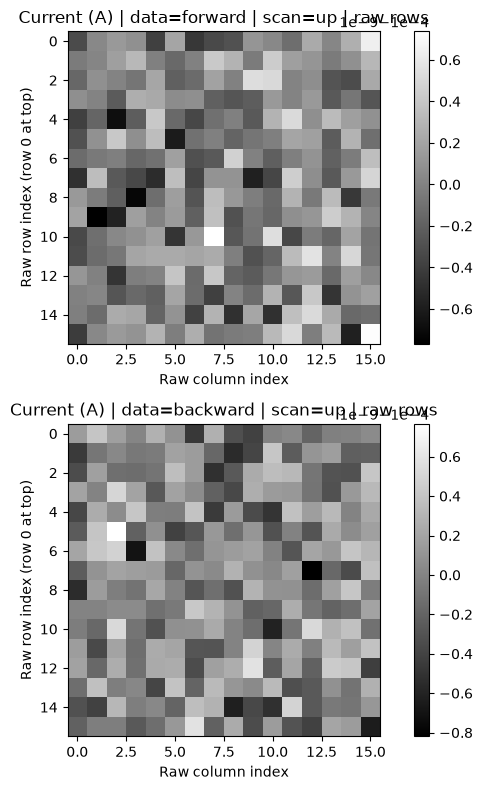

In [21]:
import matplotlib.pyplot as plt  # noqa: E402
from skimage.util import img_as_float  # noqa: E402

if not result.images:
    print("No images were requested (`grab_data=False`)")
else:
    fig, axes = plt.subplots(
        len(result.images), 1, figsize=(7, 4 * len(result.images)), squeeze=False
    )
    for axis, image in zip(axes[:, 0], result.images):
        scan_image = img_as_float(image.data)
        rows, columns = scan_image.shape
        plotted = axis.imshow(
            scan_image, cmap="gray", origin="upper", aspect="equal"
        )
        axis.set_box_aspect(rows / columns)
        axis.set_title(
            f"{image.name} | data={image.direction} | scan={image.scan_direction} | raw rows"
        )
        axis.set_xlabel("Raw column index")
        axis.set_ylabel("Raw row index (row 0 at top)")
        fig.colorbar(plotted, ax=axis)
    fig.tight_layout()

## 13. Partial scan — stop after N image rows (`run_partial`)

`ScanWorkflow.run_partial(config, max_lines=N, on_line=...)` scans at most `N` **image rows** of the frame, then sends `Scan.Action(Stop)`. It reuses the same preflight → snapshot → apply → restore transaction as `run`: it preflights read-only, forces continuous off, restores your original scan settings on exit, and runs the same reconnect → Stop recovery if anything fails after the start.

Behaviour characterized on this controller (see `examples/verify_waitendofline.py`):

- **`max_lines` counts image rows**, not raw `Scan.WaitEndOfLine` returns. The tip emits ~2 returns per row (trace + retrace) plus a short startup transient; a row is counted at each *trace* return (`movement == 0`, `line_number >= 1`).
- **`on_line(line_number, movement, pass_number)`** fires after *every* `WaitEndOfLine` return (once per movement, not per row). Return `False` to abort immediately — the "scan a few lines, inspect, then decide" hook.
- Partial scans are **not auto-saved**: `result.saved_path` is `""`.
- Rows never scanned return as **NaN**; keep `NaNPolicy.WARN`/`ALLOW`, not `RAISE`.
- Because `restore_state=True`, the controller's original buffer is restored afterward — read the partial image from the returned `result`, not from the live buffer.

`config.acquisition_timeout` governs the whole-frame `WaitEndOfScan` and is ignored here; a per-line socket timeout is derived from the effective line timing. As with the full scan, edit the explicit confirmation token below to start.

In [ ]:
# Safe default: edit this value to "START_PARTIAL_SCAN" only when the hardware is ready.
partial_confirmation = "START_PARTIAL_SCAN"
PARTIAL_MAX_LINES = 6  # image rows to acquire before stopping early

partial_result = None
line_returns = []  # every Scan.WaitEndOfLine return, one per tip movement


def on_partial_line(line_number, movement, pass_number):
    line_returns.append((line_number, movement, pass_number))
    # Return False to abort early, e.g. after a drift or feature check:
    #     return False if line_number >= 3 else None
    return None


if partial_confirmation != "START_PARTIAL_SCAN":
    print('Partial scan not started. Set partial_confirmation = "START_PARTIAL_SCAN" and rerun.')
else:
    print(
        f"Starting partial scan: {PARTIAL_MAX_LINES} rows of a "
        f"{config.lines}-line frame...",
        flush=True,
    )
    partial_result = workflow.run_partial(
        config, max_lines=PARTIAL_MAX_LINES, on_line=on_partial_line
    )

    traces = [r for r in line_returns if r[1] == 0 and r[0] >= 1]
    finite_rows = int(np.isfinite(partial_result.images[0].data).any(axis=1).sum())
    print("REAL PARTIAL SCAN FINISHED")
    print("WaitEndOfLine returns   :", len(line_returns))
    print("Trace returns (= rows)  :", len(traces))
    print("Finite data rows        :", finite_rows, "/", config.lines)
    print("Saved path (empty)      :", repr(partial_result.saved_path))
    print("Acquisition duration    :", partial_result.acquisition_duration, "s")
    print("First few returns (line, movement, pass):", line_returns[:5])

In [ ]:
if partial_result is None:
    print('Run the partial-scan cell with partial_confirmation = "START_PARTIAL_SCAN" first')
else:
    import matplotlib.pyplot as plt  # noqa: E402

    image = partial_result.images[0]
    fig, axis = plt.subplots(figsize=(6, 6))
    plotted = axis.imshow(image.data, cmap="gray", origin="upper", aspect="equal")
    axis.set_title(
        f"{image.name} | partial {PARTIAL_MAX_LINES} rows | NaN = unscanned"
    )
    axis.set_xlabel("Raw column index")
    axis.set_ylabel("Raw row index (row 0 at top)")
    fig.colorbar(plotted, ax=axis)
    fig.tight_layout()

## 14. Result and normalization helpers

`inspect_non_finite_scan_data(result)` counts NaN/Inf values and names affected images. `apply_scan_nan_policy` applies `ALLOW`, `WARN`, or `RAISE` to an already-built result. With `RAISE`, `NonFiniteScanDataError.result` retains the result.

`normalize_scan_images` validates raw `FrameDataGrab` declarations and converts wire scan direction 1/0 into `up`/`down`, without flipping data. `normalize_scan` assembles the final immutable result and applies the selected non-finite policy. The workflow normally calls both; the synthetic example below demonstrates their contracts without hardware I/O.

In [ ]:
diagnostics = inspect_non_finite_scan_data(result)
print("Real-result non-finite diagnostics:", diagnostics)
same_result = apply_scan_nan_policy(result, NaNPolicy.WARN)
assert same_result is result

synthetic_raw = {
    "channel_name": "Synthetic",
    "scan_data_rows": 2,
    "scan_data_columns": 3,
    "scan_data": np.array([[1.0, 2.0, 3.0], [4.0, np.nan, 6.0]]),
    "scan_direction": DIRECTION_UP,
}
synthetic_images = normalize_scan_images([(0, "forward", synthetic_raw)])
print("Synthetic immutable image:", synthetic_images[0])

# Re-normalize the real images to demonstrate the public constructor helper.
rechecked_result = normalize_scan(
    result.images,
    saved_path=result.saved_path,
    config=result.requested_config,
    effective=result.effective_settings,
    acquisition_started_at=result.acquisition_started_at,
    acquisition_finished_at=result.acquisition_finished_at,
    acquisition_duration=result.acquisition_duration,
    estimated_acquisition_duration=result.estimated_acquisition_duration,
    acquisition_timeout_used=result.acquisition_timeout_used,
    nan_policy=NaNPolicy.ALLOW,
)
print("Re-normalized image count:", len(rechecked_result.images))

## 15. Optional direct `grab_frame` characterization

`grab_frame(client, effective_settings, config)` sends one read command per channel × data direction and normalizes the responses. It does not start motion, but it reads the **currently buffered** frame. Because the workflow restores original buffer settings, the requested acquisition channels might no longer be current. This cell therefore snapshots the current buffer and creates a matching read configuration.

Use it to repeat raw-buffer reads while investigating row/column orientation. Do not infer physical coordinates from the returned rows yet.

In [ ]:
grab_confirmation = input(
    "Type GRAB_CURRENT_FRAME to read current scan buffers, or press Enter to skip: "
).strip()
if grab_confirmation == "GRAB_CURRENT_FRAME":
    current_settings = ScanSettings.snapshot(nanonis)
    current_grab_config = ScanConfig(
        channel_indexes=current_settings.channels,
        data_directions=("forward", "backward"),
        grab_data=True,
    )
    directly_grabbed = grab_frame(nanonis, current_settings, current_grab_config)
    for image in directly_grabbed:
        print(image.name, image.direction, image.scan_direction, image.data.shape)
else:
    print("Direct frame grab skipped")

## 16. Emergency `recover_scan` only

`recover_scan` reconnects the TCP stream, queries `Scan.StatusGet`, sends `Scan.Action(Stop, 0)` if running, and polls until idle or the recovery deadline. Its `RecoveryReport.restoration_allowed` is true only when transport is ready and stop is confirmed.

The workflow invokes this automatically after any unconfirmed post-start failure. Do not run this cell during a scan you want to keep. Pause/resume are not recovery operations.

In [ ]:
recovery_confirmation = input(
    "Type RECOVER_SCAN to reconnect and stop the scan module, or press Enter to skip: "
).strip()
if recovery_confirmation == "RECOVER_SCAN":
    recovery_report = recover_scan(
        nanonis,
        timeout=config.recovery_timeout,
        poll_interval=config.status_poll_interval,
    )
    print(recovery_report)
    print("Restoration allowed:", recovery_report.restoration_allowed)
else:
    print("Recovery skipped")

## 17. QCoDeS persistence status

Scan persistence is deliberately deferred. `nanonis.qcodes.scan.register_scan_result` and `add_scan_result` currently raise `NotImplementedError`; do not call them in this notebook. The future adapter must use 2-D setpoint meshgrids matching each image shape. Physical X/Y grids are additionally blocked on the live row-orientation characterization above. Save `result.images`, `result.effective_settings`, timestamps, and `result.saved_path` through your lab's approved interim format if needed.

## 18. Disconnect

Run this final cell when testing is finished. If a scan may still be running, use the explicitly armed recovery cell first; disconnecting alone does not stop hardware motion.

In [ ]:
nanonis.disconnect()
print("Connected:", nanonis.is_connected)
print("Transport state:", nanonis.transport_state)